# Attention Mechanisms
An **attention mechanism** learns how to score the *importance* of each item in the input.
It takes into account *context* to infer the importance of the items.
## Attention mechanisms learn relative input importance

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import torch
import torchvision
from torchvision import transforms, datasets
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm.autonotebook import tqdm
from sklearn.metrics import accuracy_score

# Import dl_utils
import sys, os
sys.path.insert(0, os.path.abspath("../DL_utils_EZA"))
%load_ext autoreload
%autoreload 2
from dl_utils import *
print("dl_utils loaded ✅")

# ── Device setup ──────────────────────────────────────────────────────────────
# cudnn.benchmark = True  → optimal for fixed-size inputs (convolutional GANs)
# cudnn.benchmark = False → safer for FC-only GANs with variable shapes
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if device.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

/tmp/ipykernel_12550/1858903610.py:10: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


dl_utils loaded ✅
Device : cuda
GPU    : NVIDIA GeForce RTX 2080 Ti
VRAM   : 11.35 GB


In [2]:
# Downloading the MNIST data set
mnist_data_train = torchvision.datasets.MNIST("./data", train=True, download=True, transform=transforms.ToTensor())
mnist_data_test = torchvision.datasets.MNIST("./data", train=False, download=True, transform=transforms.ToTensor())


In [3]:
class LargestDigit(Dataset):
    """ 
    Creates a modified version of a dataset where some number of samples are taken, 
    and the true labes is the largest label sampled. When used with MNIST, the labels
    correspond to their values (g.g., digit : '6' has label 6)
    """

    def __init__(self, dataset, toSample=3):
        """ 
        dataset:  the data set to sample from (e.g., MNIST)
        toSample: the number of samples to take from the dataset for each new sample
        """
        self.dataset = dataset
        self.toSample = toSample

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        # Randomly select `toSample` samples from the dataset
        selected = np.random.randint(0, len(self.dataset), size=self.toSample)
        # Stack the selected samples and find the maximum label
        x_new = torch.stack([self.dataset[i][0] for i in selected])
        y_new = max([self.dataset[i][1] for i in selected])
        
        return x_new, y_new

In [4]:
# Training the baseline model
B = 128
epochs = 30
largest_train = LargestDigit(mnist_data_train, toSample=3)
largest_test = LargestDigit(mnist_data_test, toSample=3)

# Data Loader
mnist_train_loader = DataLoader(largest_train, 
                                batch_size=B, 
                                shuffle=True, 
                                num_workers=4, 
                                pin_memory=True, 
                                persistent_workers=True,
                                drop_last=True
                                )
mnist_test_loader = DataLoader(largest_test, 
                               batch_size=B,
                               shuffle=False,
                               num_workers=4,
                               pin_memory=True, 
                               persistent_workers=True
                               )

True label is =  9


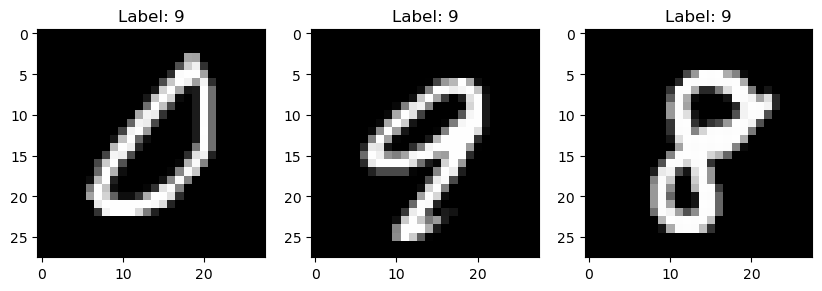

In [5]:
# Plot the transformed dataset to show that the set can 
# teach the model to ignore the smaller digists
x, y = largest_train[0]
f, axarr = plt.subplots(1, 3, figsize=(10, 10))
for i in range(3):
    axarr[i].imshow(x[i][0], cmap='gray')
    axarr[i].set_title(f"Label: {y}")
print('True label is = ', y)

In [6]:
# Train the baseline model with toy MNIST problem
neurons = 256
classes = 10
simpleNet = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784*3, neurons),
    nn.LeakyReLU(),
    nn.BatchNorm1d(neurons),
    nn.Linear(neurons, neurons),
    nn.LeakyReLU(),
    nn.BatchNorm1d(neurons),
    nn.Linear(neurons, neurons),
    nn.LeakyReLU(),
    nn.BatchNorm1d(neurons),
    nn.Linear(neurons, classes)
)

In [7]:
#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run
torch.backends.cudnn.benchmark = False  # True is better for CNNs with fixed input sizes

# train_network_EZA instructions:
"""
                      (model, 
                      loss_func, 
                      train_loader, 
                      test_loader=None,
                      score_funcs=None, 
                      epochs=300, 
                      device='cpu',                      
                      checkpoint_file=None, 
                      resume_from_checkpoint=None,
                      checkpoint_every_x=None, 
                      use_amp=True,
                      optimizer=None,
                      lr_schedule=None,
                      val_loader=None)seg_results

    Train neural networks with EZA improvements.

    Keyword arguments:
    model                  -- PyTorch model to train
    loss_func              -- loss function (outputs, labels) -> score
    train_loader           -- DataLoader returning (input, label) tuples
    test_loader            -- Optional DataLoader for evaluation after every epoch
    score_funcs            -from sklearn.metrics import accuracy_score- dict of scoring functions e.g. {'Accuracy': accuracy_score}
    epochs                 -- number of training epochs
    device                 -- 'cuda' or 'cpu'
    checkpoint_file        -- path to save final checkpoint
    resume_from_checkpoint -- path to load checkpoint from to resume training
    checkpoint_every_x     -- save intermediate checkpoint every X epochs
    use_amp                -- enable Automatic Mixed Precision (RTX GPUs)
    optimizer              -- if none selected it uses AdamW optimizer
    lr_schedule            -- uses the ReduceLROPlateu function.
    val_loader             -- Optional PyTorch DataLoader to evaluate on after every epoch

    Returns: pd.DataFrame with training history

    ---------------seg_results---------------------------------------------------------------------------
    
    Improves over the train_simple_network:
    - Uses new optimizers and schedulers

"""

simple_results = train_network_EZA(simpleNet,
                                   nn.CrossEntropyLoss(),
                                   mnist_train_loader,
                                   val_loader=mnist_test_loader,
                                   epochs=10,
                                   use_amp=True,
                                   score_funcs= {'Accuracy': accuracy_score},
                                   device=device)

Epoch: 100%|██████████| 10/10 [02:49<00:00, 16.96s/it]


<Axes: xlabel='epoch', ylabel='val loss'>

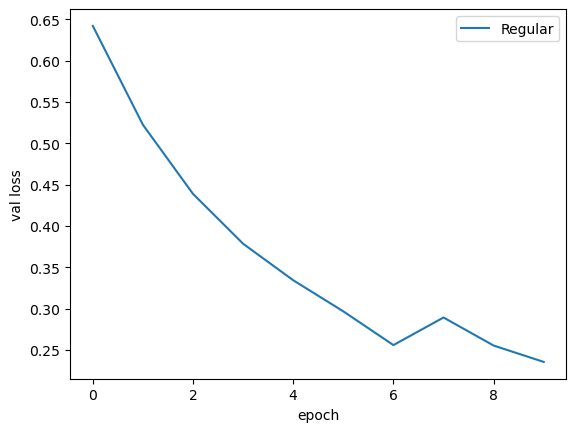

In [8]:
sns.lineplot(x="epoch", y="val loss", data=simple_results, label="Regular")

<Axes: xlabel='epoch', ylabel='val Accuracy'>

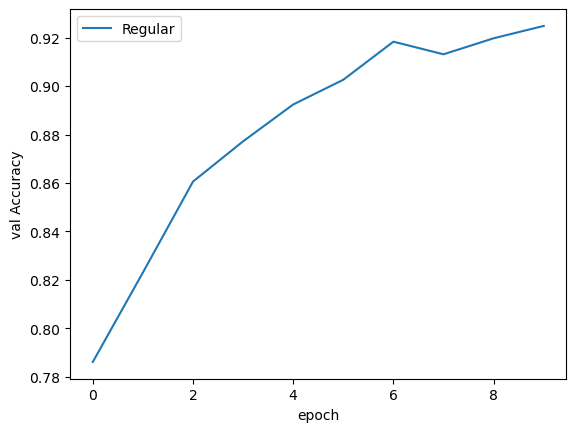

In [9]:
sns.lineplot(x="epoch", y="val Accuracy", data=simple_results, label="Regular")

### Implementing a simple **Attention Mechanism**
We need to convert the bag of images  (B,T,C,W,H) into a bag of feature vectors (B, T, C * W * H) using the `nn.Flatten` function.

In [10]:
# Flatten function
class Flatten2(nn.Module):
    """ 
    Takes a vector of shape (A,B,C,D, ...)
    and flattens all but the first two dimensions, returning a vector of shape (A,B,C*D*...)
    """
    def forward(self, input):
        return input.view(input.size(0), input.size(1), -1)

**DEFINING THE COMBINER MODULE**\
A module that takes the attention weights $a$ with the extracted feature representations $h_1, h_2, ...h_T$ and computes the  the weighted average. Call the `Combiner`.

In [11]:
# The Combiner Module
class Combiner(nn.Module):
    """
    Combines a set of vectors into a single vector using attention weights.
    """
    def __init__(self, featureExtraction, weightSelection):
        """ 
        featureExtraction: a network that takes an input shape (B,T,D) and ouputs a new
        shape (B,T,D') where D' is the new feature dimension
        weightSelection: a network that takes an input shape (B,T,1) or (B,T). it shoule be 
        normalized, so that T values sum to 1.
        """
        super(Combiner, self).__init__()
        self.featureExtraction = featureExtraction
        self.attention = weightSelection
        

    def forward(self, input):
        """ 
        input:  tensor of shape (B, T, D)
        return: new tensor of shape (B, D') where D' is the new feature dimension
        """
        features = self.featureExtraction(input)  # (B, T, D')
        weights = self.attention(features)            # (B, T, 1) or (B, T)
        if len(weights.shape) == 2:
            weights = weights.unsqueeze(2)  # (B, T, 1)
        r = features * weights  # (B, T, D')
        return torch.sum(r, dim=1)  # (B, D')


**DEFINING A BACKBONE NETWORK**

Define the attention model for this problem. It will learn a good representation of **$h_i$**\
Define variables: 
- T = items in the bag
- D = number of features

In [12]:
# Variables
T = 3
D = 784
D_prime = 256

# xb, yb = next(iter(mnist_train_loader))

# flatten2 = Flatten2()
# xb_flat = flatten2(xb) 

backboneNetwork = nn.Sequential(
    Flatten2(),
    nn.Linear(D, D_prime),
    nn.LeakyReLU(),
    nn.Linear(D_prime, D_prime),
    nn.LeakyReLU(),
    nn.Linear(D_prime, D_prime),
    nn.LeakyReLU())

**DEFINING AN ATTENTION SUBNETWORK**

In [13]:
attentionMechanism = nn.Sequential(
    nn.Linear(D_prime, D_prime),
    nn.LeakyReLU(),
    nn.Linear(D_prime, 1),
    nn.Softmax(dim=1),   # <- normalize over T, not over the last dim
)

In [14]:
# Training a small attention-based model
small_attention_model = nn.Sequential(
    Combiner(backboneNetwork, attentionMechanism),
    nn.BatchNorm1d(D_prime),
    nn.Linear(D_prime, D_prime),
    nn.LeakyReLU(),
    nn.BatchNorm1d(D_prime),
    nn.Linear(D_prime, classes),
).to(device)

T = 3
D = 784

In [15]:

#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run
torch.backends.cudnn.benchmark = False  # True is better for CNNs with fixed input sizes

optimizer = torch.optim.AdamW(small_attention_model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

# Train the small attention-based model
small_attn_results = train_network_EZA(
    model=small_attention_model,
    loss_func=nn.CrossEntropyLoss(),
    train_loader=mnist_train_loader,
    val_loader=mnist_test_loader,
    score_funcs={'Accuracy': accuracy_score},
    epochs=10,
    device=device,
    use_amp=True,          # safe: Turing supports fp16, GradScaler already wired in dl_utils
    optimizer=optimizer,
    lr_schedule=scheduler
)

Epoch: 100%|██████████| 10/10 [02:47<00:00, 16.73s/it]


<Axes: xlabel='epoch', ylabel='val loss'>

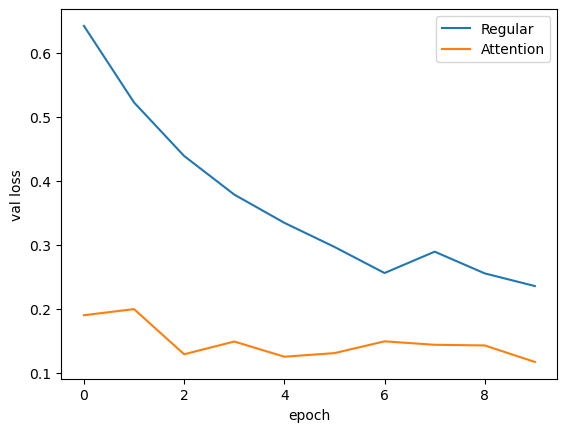

In [16]:
sns.lineplot(x="epoch", y="val loss", data=simple_results, label="Regular")
sns.lineplot(x="epoch", y="val loss", data=small_attn_results, label="Attention")

<Axes: xlabel='epoch', ylabel='val Accuracy'>

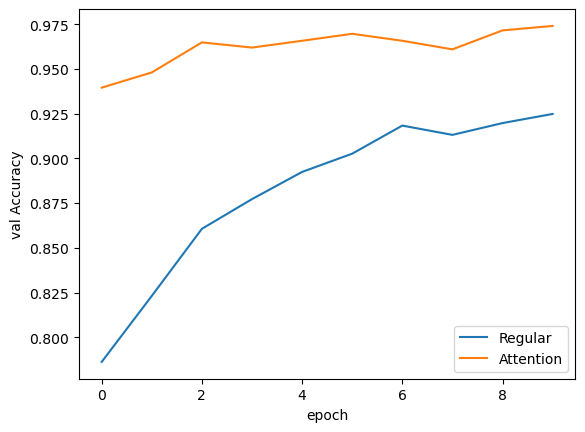

In [17]:
sns.lineplot(x="epoch", y="val Accuracy", data=simple_results, label="Regular")
sns.lineplot(x="epoch", y="val Accuracy", data=small_attn_results, label="Attention")

True Label is =  5


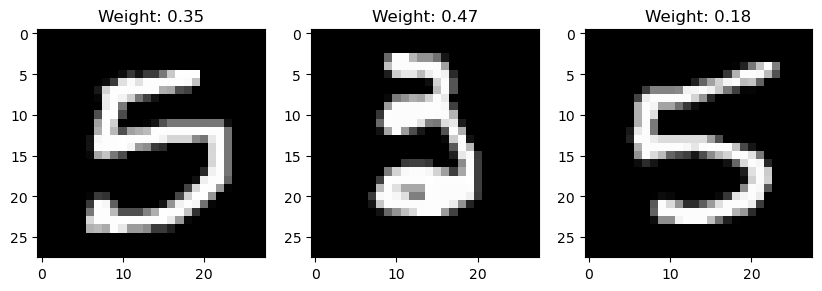

In [18]:
# Review how the attention mechanism select the results.
x, y = largest_train[0]
x = x.to(device)

with torch.no_grad():
    weigths = attentionMechanism(backboneNetwork(x.unsqueeze(0)))
    weigths = weigths.cpu().numpy().ravel()

f, axarr = plt.subplots(1, 3, figsize=(10, 10))
for i in range(3):
    axarr[i].imshow(x[i][0].cpu(), cmap='gray')
    axarr[i].set_title(f"Weight: {weigths[i]:.2f}")

print("True Label is = ", y)

`LargestDigit` dataset only returns `(x_new, y_new)` — the three images and the bag's label (the max). It throws away which of the three images actually held that largest digit, so there's currently no way to check "did attention look at the right one." 

Add a small subclass for inspection only

In [19]:
class LargestDigitDebug(LargestDigit):
    """Same sampling as LargestDigit, but also returns the individual item
    labels so we can check whether attention focused on the right image."""
    def __getitem__(self, idx):
        selected = np.random.randint(0, len(self.dataset), size=self.toSample)
        x_new = torch.stack([self.dataset[i][0] for i in selected])
        item_labels = torch.tensor([self.dataset[i][1] for i in selected])
        y_new = item_labels.max().item()
        return x_new, y_new, item_labels

debug_test = LargestDigitDebug(mnist_data_test, toSample=3)

#### Qualitative: look at a handful of bags

/tmp/ipykernel_12550/2178763064.py:30: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/efrain/anaconda3/envs/pytorch-gpu/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


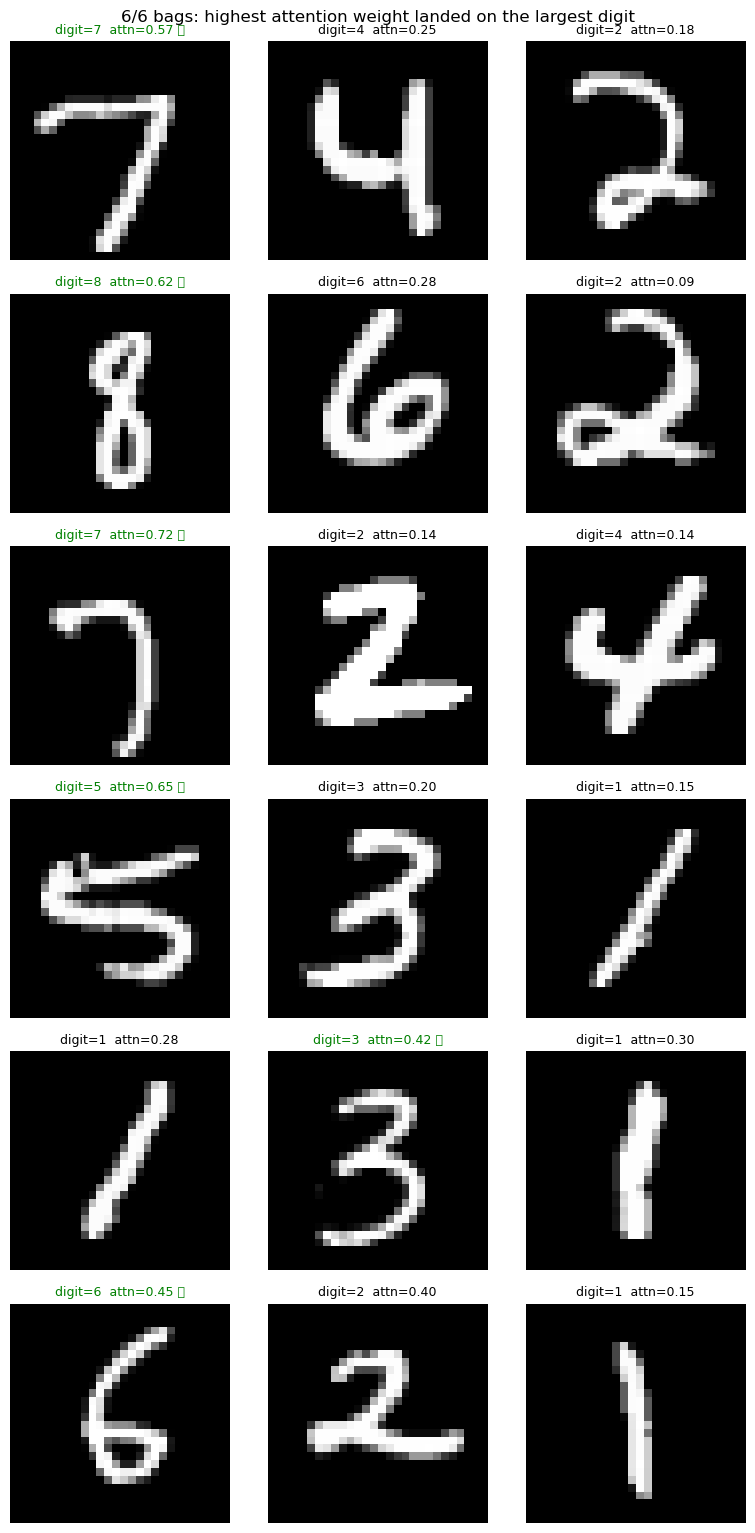

In [20]:
def visualize_attention(backbone, attention, debug_dataset, device, n_examples=6, seed=0):
    rng = np.random.RandomState(seed)
    indices = rng.choice(len(debug_dataset), n_examples, replace=False)
    backbone.eval(); attention.eval()

    fig, axarr = plt.subplots(n_examples, 3, figsize=(8, 2.6 * n_examples))
    n_correct = 0

    with torch.no_grad():
        for row, idx in enumerate(indices):
            x, y, item_labels = debug_dataset[idx]          # x: (T, C, H, W)
            xb = x.unsqueeze(0).to(device)                   # (1, T, C, H, W)

            features = backbone(xb)                          # (1, T, D')
            weights = attention(features).squeeze().cpu().numpy()   # (T,)

            true_idx = item_labels.argmax().item()
            attn_idx = weights.argmax()
            n_correct += int(attn_idx == true_idx)

            for col in range(3):
                ax = axarr[row, col]
                ax.imshow(x[col, 0].numpy(), cmap='gray')
                ax.axis('off')
                marker = " ✅" if col == true_idx else ""
                ax.set_title(f"digit={item_labels[col].item()}  attn={weights[col]:.2f}{marker}",
                              fontsize=9, color='green' if col == attn_idx else 'black')

    plt.suptitle(f"{n_correct}/{n_examples} bags: highest attention weight landed on the largest digit")
    plt.tight_layout()
    plt.show()

visualize_attention(backboneNetwork, attentionMechanism, debug_test, device, n_examples=6)

#### Quantitative: alignment rate over many bags

In [21]:
def attention_alignment_rate(backbone, attention, debug_dataset, device,
                                 n_samples=1000, batch_size=128, seed=0):
    rng = np.random.RandomState(seed)
    indices = rng.choice(len(debug_dataset), n_samples, replace=False)
    backbone.eval(); attention.eval()
    correct = 0

    with torch.no_grad():
        for start in range(0, n_samples, batch_size):
            xs, labels = [], []
            for idx in indices[start:start + batch_size]:
                x, y, item_labels = debug_dataset[idx]
                xs.append(x); labels.append(item_labels)
            xb = torch.stack(xs).to(device)
            labels = torch.stack(labels)                        # (B, T)
            is_max = labels == labels.max(dim=1, keepdim=True).values   # (B, T) bool

            weights = attention(backbone(xb)).squeeze(-1).cpu()  # (B, T)
            pred_idx = weights.argmax(dim=1)                     # (B,)

            correct += is_max[torch.arange(len(pred_idx)), pred_idx].sum().item()

    rate = correct / n_samples
    print(f"Attention landed on a VALID largest-digit item (ties counted correct) in "
          f"{correct}/{n_samples} bags ({rate*100:.1f}%)")
    return rate

attention_alignment_rate(backboneNetwork, attentionMechanism, debug_test, device, n_samples=1000)

Attention landed on a VALID largest-digit item (ties counted correct) in 854/1000 bags (85.4%)


0.854

## Adding *CONTEXT*
To add context we can simply use the average value of all the features extracted. This occurs in three steps:
1. Compute the average of the featrues extracted from each input. This treats everything as being equal in importance
2. Compute attention scores **$\alpha$** for the $T$ inputs including the average **$h$** as second argument to each score.
3. Compute the weighted average of the extracted features.

There are 3 methods to compute the socre from the $h$ representation:
- **Dot score**
- **General score**
- **Additive scores**

### Dot score
It uses the *dot score* equation to establish the relationship of two variables. For the implementation we use the batch matrix multiply method `torch.bmm`, follow by the `unsqueeze` method to add a dimension of size 1.

In [22]:
class DotScore(nn.Module):
    """ 
    Computes the dot product between a query vector and a set of key vectors.
    """
    def __init__(self, H):
        """ 
        H: the dimension of the query and key vectors
        """
        super(DotScore, self).__init__()
        self.H = H

    def forward(self, states, context):
        """ 
        states: tensor of shape (B, T, H)
        context: tensor of shape (B, H)
        return: tensor of shape (B, T) containing the dot product between each state and the context
        """
        T = states.size(1)
        scores = torch.bmm(states, context.unsqueeze(2))/np.sqrt(self.H)  # (B, T, 1)
        return scores
    

### General score
It uses a *bilinear relationship* function to add a matrix between each item $h_t$.\
Implemented with the `nn.Bilinear(H1, H2, out_size)` function in PyTorch.

In [48]:
class GeneralScore(nn.Module):
    """ 
    Computes the general score between a query vector and a set of key vectors.
    """
    def __init__(self, H):
        """ 
        H: the dimension of the query and key vectors
        """
        super(GeneralScore, self).__init__()
        self.w = nn.Bilinear(H, H, 1)

    def forward(self, states, context):
        """ 
        states: tensor of shape (B, T, H)
        context: tensor of shape (B, H)
        return: tensor of shape (B, T) containing the general score between each state and the context
        """
        T = states.size(1)
        context = torch.stack([context for _ in range(T)], dim=1)  # (B, T, H)
        scores = self.w(states, context)
        return scores


### Additive attention or concat attention
For a given vector and its context **v** and a matrix **W** as the paramters for the layer, making a small neural network. So the small neural network figure out the weighthing for us. It uses `nn.Linear` and `torch.cat` functions.

In [ ]:
class AdditiveAttentionScore(nn.Module):
    """ 
    Computes the additive score between a query vector and a set of key vectors.
    """
    def __init__(self, H):
        """ 
        H: the dimension of the query and key vectors
        """
        super(AdditiveAttentionScore, self).__init__()
        self.v = nn.Linear(H, H, 1)
        self.w = nn.Linear(2*H, H)

    def forward(self, states, context):
        """ 
        states: tensor of shape (B, T, H)
        context: tensor of shape (B, H)
        return: tensor of shape (B, T) containing the additive score between each state and the context
        """
        T = states.size(1)
        context = torch.stack([context for _ in range(T)], dim=1)  # (B, T, H)
        state_context_combined = torch.cat([states, context], dim=2)  # (B, T, 2H)
        scores = self.v(torch.tanh(self.w(state_context_combined)))
        return scores
    

### Computing attention weights
We se a helper module to compute the final output. It replaces the `Combine` module by adding a *mask* to the inputs.

In [38]:
class ApplyAttention(nn.Module):
    """ 
    Applies attention to a set of states given a context vector.
    """
    def __init__(self):
        """ 
        score_func: a function that computes the score between a set of states and a context vector
        """
        super(ApplyAttention, self).__init__()

    def forward(self, states, attention_scores, mask=None):
        """ 
        states: tensor of shape (B, T, H)
        attention_scores: tensor of shape (B, T)
        mask: tensor of shape (B, T) containing the mask for the attention scores
        return: tensor of shape (B, H) containing the weighted sum of the states
        """
        if mask is not None:
            attention_scores = attention_scores.masked_fill(~mask.unsqueeze(-1), -1000)
        weights = F.softmax(attention_scores, dim=1)
        final_context = (states*weights).sum(dim=1)
        return final_context, weights

In [27]:
def getMaskByFill(x, time_dimension=1, fill=0):
    """ 
    x: Original input tensor of shape (B, T, ...)
    time_dimension: The dimension that represents time (T)
    fill: The value that represents padding in the time dimension
    return: A boolean mask of shape (B, T) where True indicates a valid time step and False indicates a padded time step
    """
    to_sum_over = list(range(1, len(x.shape)))
    if time_dimension in to_sum_over:
        to_sum_over.remove(time_dimension)
    with torch.no_grad():
        mask = torch.sum((x != fill), dim=to_sum_over) > 0
    return mask

In [28]:
# Test the mask function with hypothethical sample
with torch.no_grad():
    x = torch.rand((5,3,1,7,7))
    x[0,-1,:] = 0
    x[3,:] = 0
    x[4,0,0,0,] = 0
    mask = getMaskByFill(x)
    print(mask)

tensor([[ True,  True, False],
        [ True,  True,  True],
        [ True,  True,  True],
        [False, False, False],
        [ True,  True,  True]])


## A complete *ATTENTION MECHANISM*  with *Context*
For attention-base models we DO NOT use `nn.Sequential` as there are non-sequential steps in attention. It is used to organize subnetworks instead.\
### Define a `SmarterAttentionNet` for the entire network

In [29]:
class SmarterAttentionNet(nn.Module):
    def __init__(self, input_size, hidden_size, out_size, score_net=None):
        super(SmarterAttentionNet, self).__init__()
        self.backbone = nn.Sequential(
            Flatten2(),
            nn.Linear(input_size, hidden_size),
            nn.LeakyReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.LeakyReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.LeakyReLU()
        )
        self.score_net = AdditiveAttentionScore(hidden_size) if score_net is None else score_net
        self.apply_attn = ApplyAttention()
        self.prediction_net = nn.Sequential(
            nn.BatchNorm1d(hidden_size),
            nn.Linear(hidden_size, hidden_size),
            nn.LeakyReLU(),
            nn.BatchNorm1d(hidden_size),
            nn.Linear(hidden_size, out_size)
        )

    def forward(self, input):
        mask = getMaskByFill(input)
        h = self.backbone(input)
        h_context = (mask.unsqueeze(-1) * h).sum(dim=1) / (mask.sum(dim=1).unsqueeze(-1)+1e-10)
        scores = self.score_net(h, h_context)
        final_context, _ = self.apply_attn(h, scores, mask=mask)
        return self.prediction_net(final_context)

### Test the 3 attention modules

In [49]:
# test the attention modules
attn_dot = SmarterAttentionNet(
    D, neurons, classes, score_net=DotScore(neurons)
)

attn_gen = SmarterAttentionNet(
    D, neurons, classes, score_net=GeneralScore(neurons)
)

attn_add = SmarterAttentionNet(
    D, neurons, classes, score_net=AdditiveAttentionScore(neurons)
)


In [ ]:
#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run
torch.backends.cudnn.benchmark = False  # True is better for CNNs with fixed input sizes

optimizer = torch.optim.AdamW(attn_dot.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

# Train the smarter attention-based model
attn_results_dot = train_network_EZA(
    model=attn_dot,
    loss_func=nn.CrossEntropyLoss(),
    train_loader=mnist_train_loader,
    val_loader=mnist_test_loader,
    score_funcs={'Accuracy': accuracy_score},
    epochs=10,
    device=device,
    use_amp=True,          # safe: Turing supports fp16, GradScaler already wired in dl_utils
    optimizer=optimizer,
    lr_schedule=scheduler
)

Epoch: 100%|██████████| 10/10 [02:48<00:00, 16.84s/it]


In [50]:
#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run
torch.backends.cudnn.benchmark = False  # True is better for CNNs with fixed input sizes

optimizer = torch.optim.AdamW(attn_gen.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

# Train the smarter attention-based model
attn_results_gen = train_network_EZA(
    model=attn_gen,
    loss_func=nn.CrossEntropyLoss(),
    train_loader=mnist_train_loader,
    val_loader=mnist_test_loader,
    score_funcs={'Accuracy': accuracy_score},
    epochs=10,
    device=device,
    use_amp=True,          # safe: Turing supports fp16, GradScaler already wired in dl_utils
    optimizer=optimizer,
    lr_schedule=scheduler
)

Epoch: 100%|██████████| 10/10 [02:49<00:00, 16.94s/it]


In [47]:
#  reset workers before new run
import gc
gc.collect()
torch.cuda.empty_cache()  # Free any leftover VRAM from previous run
torch.backends.cudnn.benchmark = False  # True is better for CNNs with fixed input sizes

optimizer = torch.optim.AdamW(attn_add.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

# Train the smarter attention-based model
attn_results_add = train_network_EZA(
    model=attn_add,
    loss_func=nn.CrossEntropyLoss(),
    train_loader=mnist_train_loader,
    val_loader=mnist_test_loader,
    score_funcs={'Accuracy': accuracy_score},
    epochs=10,
    device=device,
    use_amp=True,          # safe: Turing supports fp16, GradScaler already wired in dl_utils
    optimizer=optimizer,
    lr_schedule=scheduler
)

Epoch: 100%|██████████| 10/10 [03:11<00:00, 19.18s/it]


<Axes: xlabel='epoch', ylabel='val loss'>

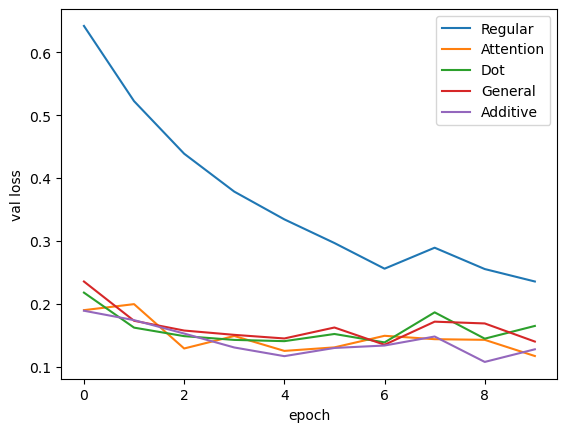

In [51]:
sns.lineplot(x="epoch", y="val loss", data=simple_results, label="Regular")
sns.lineplot(x="epoch", y="val loss", data=small_attn_results, label="Attention")
sns.lineplot(x="epoch", y="val loss", data=attn_results_dot, label="Dot")
sns.lineplot(x="epoch", y="val loss", data=attn_results_gen, label="General")
sns.lineplot(x="epoch", y="val loss", data=attn_results_add, label="Additive")

<Axes: xlabel='epoch', ylabel='val Accuracy'>

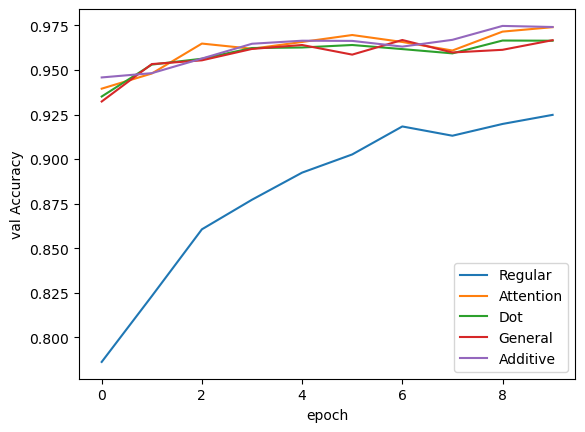

In [52]:
sns.lineplot(x="epoch", y="val Accuracy", data=simple_results, label="Regular")
sns.lineplot(x="epoch", y="val Accuracy", data=small_attn_results, label="Attention")
sns.lineplot(x="epoch", y="val Accuracy", data=attn_results_dot, label="Dot")
sns.lineplot(x="epoch", y="val Accuracy", data=attn_results_gen, label="General")
sns.lineplot(x="epoch", y="val Accuracy", data=attn_results_add, label="Additive")

#### Verify that the code handles variable-sized inputs with `LargestDigitVariable` class

In [56]:
class LargestDigitVariable(Dataset):
    """
    Creates a modified version of a dataset where some variable number of samples
    are taken, and the true label is the largest label sampled. When used with MNIST, the labels
    correspond to their values (g.g., digit : '6' has label 6).
    Each datum will be padded with zeros if the maxium number of itemes was not sampled.
    """
    def __init__(self, dataset, maxSample=6):
        """ 
        dataset:  the data set to sample from (e.g., MNIST)
        maxSample: the maximum number of samples to take from the dataset for each new sample
        """
        self.dataset = dataset
        self.maxSample = maxSample

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        # Randomly select a number of samples between minSample and maxSample
        n_samples = np.random.randint(1, self.maxSample, size=1)[0]
        selected = np.random.randint(0, len(self.dataset), size=n_samples)
        # Stack the selected samples and find the maximum label
        x_new = torch.stack([self.dataset[i][0] for i in selected] + 
                            [torch.zeros((1,28,28)) for i in range(self.maxSample - n_samples)])
        y_new = max([self.dataset[i][1] for i in selected])
        
        return x_new, y_new

In [57]:
largestV_train = LargestDigitVariable(mnist_data_train, maxSample=6)
largestV_test = LargestDigitVariable(mnist_data_test, maxSample=6)

trainV_loader = DataLoader(largestV_train, 
                           batch_size=B,
                           shuffle=True,
                           num_workers=4,
                           pin_memory=True,
                           persistent_workers=True,
                           drop_last=True
                           )

testV_loader = DataLoader(largestV_test,
                          batch_size=B,
                          shuffle=False,
                          num_workers=4,
                          pin_memory=True,
                          persistent_workers=True
                          )

In [67]:
attn_gen_V = attn_gen.to(device).eval()
preds = []
truths = []
with torch.no_grad():
    for inputs, labels in testV_loader:
        pred = attn_gen_V(inputs.to(device))
        pred = torch.argmax(pred, dim=1).cpu().numpy()
        preds.extend(pred.ravel())
        truths.extend(labels.numpy().ravel())

print("Variable Length Accuracy: ", accuracy_score(preds, truths))

Variable Length Accuracy:  0.9719
